In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

# Data inspection and cleaning

This notebook is used for initial inspection and preparation of the raw datasets for project.

The goal is composed of several objectives:
- inspect the available raw files
- understand their structure and year coverage
- identify the features relevant to the project
- begin initial cleaning(if neccessary) steps

In [2]:
# for easier execution

world_bank_path = r"C:\Users\User\Desktop\softuni lections\Data science\bulgaria_before_after_1989\data\raw\API_BGR_DS2_en_csv_v2_12004.csv"
nsi_population_path = r"C:\Users\User\Desktop\softuni lections\Data science\bulgaria_before_after_1989\data\raw\Pop_6.3_Census2011_EN.xlsx"

In [3]:
# loading of the main World Bank dataset

wb_raw = pd.read_csv(world_bank_path, skiprows = 4)
wb_raw.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Bulgaria,BGR,"Internally displaced persons, new displacement...",VC.IDP.NWDS,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,50.000000,NaN,NaN,25.000000,900.000000,250.000000,NaN,NaN,NaN
1,Bulgaria,BGR,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,21.982555,21.523882,20.371885,27.588725,25.632471,23.130965,20.573738,15.294917,NaN,NaN
2,Bulgaria,BGR,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,27.819322,30.468714,35.602935,45.740777,47.225617,46.585694,49.500847,53.292713,NaN,NaN
3,Bulgaria,BGR,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001152,0.000569,0.000752,0.000405,0.000602,0.001418,0.006864,NaN,NaN,NaN
4,Bulgaria,BGR,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.570555,0.554189,0.557143,0.522498,0.581835,0.582724,0.568542,NaN,NaN,NaN


The World Bank file is structured so that each row represents a different indicator for Bulgaria, while the years are stored as columns. This means the dataset is initially in a wide format and will likely need reshaping before analysis.

In [4]:
# inspection of indicators and their respective codes and a duplicate check

wb_raw[["Indicator Name", "Indicator Code"]].drop_duplicates()

,Indicator Name,Indicator Code
0,"Internally displaced persons, new displacement...",VC.IDP.NWDS
1,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT
2,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT
3,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS
4,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS
...,...,...
1481,"Net bilateral aid flows from DAC donors, Nethe...",DC.DAC.NLDL.CD
1482,"Net bilateral aid flows from DAC donors, Japan...",DC.DAC.JPNL.CD
1483,"Net bilateral aid flows from DAC donors, Hunga...",DC.DAC.HUNL.CD
1484,"Net bilateral aid flows from DAC donors, Finla...",DC.DAC.FINL.CD


Because of the need of only several indicators for this project, searching for the desired ones will be made.

In [5]:
wb_raw[wb_raw["Indicator Name"].str.contains("Population, total", case=False, na=False)][["Indicator Name", "Indicator Code"]].drop_duplicates()

,Indicator Name,Indicator Code
421,"Population, total",SP.POP.TOTL


In [6]:
wb_raw[wb_raw["Indicator Name"].str.contains("Fertility rate, total", case=False, na=False)][["Indicator Name", "Indicator Code"]].drop_duplicates()

,Indicator Name,Indicator Code
247,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN


In [7]:
wb_raw[wb_raw["Indicator Name"].str.contains("Mortality rate, infant", case=False, na=False)][["Indicator Name", "Indicator Code"]].drop_duplicates()

,Indicator Name,Indicator Code
45,"Mortality rate, infant, female (per 1,000 live...",SP.DYN.IMRT.FE.IN
248,"Mortality rate, infant, male (per 1,000 live b...",SP.DYN.IMRT.MA.IN
439,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN


In [8]:
wb_raw[wb_raw["Indicator Name"].str.contains("Life expectancy", case=False, na=False)][["Indicator Name", "Indicator Code"]].drop_duplicates()

,Indicator Name,Indicator Code
44,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN
438,"Life expectancy at birth, male (years)",SP.DYN.LE00.MA.IN
987,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN


In [9]:
# use the indicator codes to keep only the variables needed for the project
selected_indicator_codes = [
    "SP.POP.TOTL",
    "SP.DYN.TFRT.IN",
    "SP.DYN.IMRT.IN",
    "SP.DYN.LE00.IN"
]

wb_selected = wb_raw[wb_raw["Indicator Code"].isin(selected_indicator_codes)]

wb_selected[["Indicator Name", "Indicator Code"]]

,Indicator Name,Indicator Code
44,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN
247,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN
421,"Population, total",SP.POP.TOTL
439,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN


In [10]:
wb_selected.columns.tolist()

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 'Unnamed: 70']

In [11]:
wb_selected.shape

(4, 71)

In [12]:
wb_selected.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
44,Bulgaria,BGR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,6.924756e+01,7.019561e+01,6.949195e+01,7.030927e+01,7.112122e+01,7.129390e+01,...,7.481463e+01,7.496341e+01,7.511220e+01,7.335610e+01,7.121220e+01,7.416098e+01,7.575610e+01,7.576098e+01,NaN,NaN
247,Bulgaria,BGR,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,2.310000e+00,2.290000e+00,2.240000e+00,2.210000e+00,2.190000e+00,2.090000e+00,...,1.710000e+00,1.730000e+00,1.790000e+00,1.770000e+00,1.800000e+00,1.780000e+00,1.810000e+00,1.720000e+00,NaN,NaN
421,Bulgaria,BGR,"Population, total",SP.POP.TOTL,7.867374e+06,7.943118e+06,8.012946e+06,8.078145e+06,8.144340e+06,8.204168e+06,...,6.803468e+06,6.710798e+06,6.616726e+06,6.550696e+06,6.507301e+06,6.465097e+06,6.446596e+06,6.441421e+06,NaN,NaN
439,Bulgaria,BGR,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,4.490000e+01,4.040000e+01,3.680000e+01,3.420000e+01,3.240000e+01,3.140000e+01,...,6.100000e+00,5.800000e+00,5.500000e+00,5.300000e+00,5.200000e+00,5.000000e+00,4.800000e+00,4.600000e+00,NaN,NaN


## Observations after filtering the selected indicators

The filtered World Bank data now contains only the four indicators relevant to the project.
The dataset is still in wide format: rows represent indicators and columns represent years, which is an issue that will be going to addressed. 
There is also one extra unnamed column that appears to be empty and should be removed.

In [13]:
# removal of empty extra column

wb_selected = wb_selected.loc[:, ~wb_selected.columns.str.contains("^Unnamed")]
wb_selected.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
44,Bulgaria,BGR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,6.924756e+01,7.019561e+01,6.949195e+01,7.030927e+01,7.112122e+01,7.129390e+01,...,7.481220e+01,7.481463e+01,7.496341e+01,7.511220e+01,7.335610e+01,7.121220e+01,7.416098e+01,7.575610e+01,7.576098e+01,NaN
247,Bulgaria,BGR,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,2.310000e+00,2.290000e+00,2.240000e+00,2.210000e+00,2.190000e+00,2.090000e+00,...,1.670000e+00,1.710000e+00,1.730000e+00,1.790000e+00,1.770000e+00,1.800000e+00,1.780000e+00,1.810000e+00,1.720000e+00,NaN
421,Bulgaria,BGR,"Population, total",SP.POP.TOTL,7.867374e+06,7.943118e+06,8.012946e+06,8.078145e+06,8.144340e+06,8.204168e+06,...,6.894139e+06,6.803468e+06,6.710798e+06,6.616726e+06,6.550696e+06,6.507301e+06,6.465097e+06,6.446596e+06,6.441421e+06,NaN
439,Bulgaria,BGR,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,4.490000e+01,4.040000e+01,3.680000e+01,3.420000e+01,3.240000e+01,3.140000e+01,...,6.400000e+00,6.100000e+00,5.800000e+00,5.500000e+00,5.300000e+00,5.200000e+00,5.000000e+00,4.800000e+00,4.600000e+00,NaN


In [14]:
# checking data types

wb_selected.dtypes.head(10)

Country Name          str
Country Code          str
Indicator Name        str
Indicator Code        str
1960              float64
1961              float64
1962              float64
1963              float64
1964              float64
1965              float64
dtype: object

In [15]:
#improving number display

pd.options.display.float_format = "{:,.2f}".format
wb_selected.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
44,Bulgaria,BGR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,69.25,70.20,69.49,70.31,71.12,71.29,...,74.81,74.81,74.96,75.11,73.36,71.21,74.16,75.76,75.76,NaN
247,Bulgaria,BGR,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,2.31,2.29,2.24,2.21,2.19,2.09,...,1.67,1.71,1.73,1.79,1.77,1.80,1.78,1.81,1.72,NaN
421,Bulgaria,BGR,"Population, total",SP.POP.TOTL,"7,867,374.00","7,943,118.00","8,012,946.00","8,078,145.00","8,144,340.00","8,204,168.00",...,"6,894,139.00","6,803,468.00","6,710,798.00","6,616,726.00","6,550,696.00","6,507,301.00","6,465,097.00","6,446,596.00","6,441,421.00",NaN
439,Bulgaria,BGR,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,44.90,40.40,36.80,34.20,32.40,31.40,...,6.40,6.10,5.80,5.50,5.30,5.20,5.00,4.80,4.60,NaN


In [16]:
#check of years in the dataset
wb_selected.columns.tolist()[-10:]

['2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

In [17]:
#removing features of no use for the project

wb_selected_cleaned = wb_selected.drop(columns=["Country Name", "Country Code"])
wb_selected_cleaned.head()

,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
44,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,69.25,70.20,69.49,70.31,71.12,71.29,71.22,70.41,...,74.81,74.81,74.96,75.11,73.36,71.21,74.16,75.76,75.76,NaN
247,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,2.31,2.29,2.24,2.21,2.19,2.09,2.03,2.02,...,1.67,1.71,1.73,1.79,1.77,1.80,1.78,1.81,1.72,NaN
421,"Population, total",SP.POP.TOTL,"7,867,374.00","7,943,118.00","8,012,946.00","8,078,145.00","8,144,340.00","8,204,168.00","8,258,057.00","8,310,226.00",...,"6,894,139.00","6,803,468.00","6,710,798.00","6,616,726.00","6,550,696.00","6,507,301.00","6,465,097.00","6,446,596.00","6,441,421.00",NaN
439,"Mortality rate, infant (per 1,000 live births)",SP.DYN.IMRT.IN,44.90,40.40,36.80,34.20,32.40,31.40,31.10,30.90,...,6.40,6.10,5.80,5.50,5.30,5.20,5.00,4.80,4.60,NaN


In [18]:
# tranposition of the dataset

wb_transposed = wb_selected_cleaned.set_index("Indicator Name").drop(columns="Indicator Code").T
wb_transposed.head()

Indicator Name,"Life expectancy at birth, total (years)","Fertility rate, total (births per woman)","Population, total","Mortality rate, infant (per 1,000 live births)"
1960,69.25,2.31,"7,867,374.00",44.90
1961,70.20,2.29,"7,943,118.00",40.40
1962,69.49,2.24,"8,012,946.00",36.80
1963,70.31,2.21,"8,078,145.00",34.20
1964,71.12,2.19,"8,144,340.00",32.40


In [19]:
# transposition of features

wb_transposed = wb_transposed[
    [
        "Population, total",
        "Life expectancy at birth, total (years)",
        "Fertility rate, total (births per woman)",
        "Mortality rate, infant (per 1,000 live births)"
    ]
]

wb_transposed.head()

Indicator Name,"Population, total","Life expectancy at birth, total (years)","Fertility rate, total (births per woman)","Mortality rate, infant (per 1,000 live births)"
1960,"7,867,374.00",69.25,2.31,44.90
1961,"7,943,118.00",70.20,2.29,40.40
1962,"8,012,946.00",69.49,2.24,36.80
1963,"8,078,145.00",70.31,2.21,34.20
1964,"8,144,340.00",71.12,2.19,32.40


In [20]:
# renaming of features for better reading

wb_transposed = wb_transposed.rename(
    columns={
        "Population, total": "population_total",
        "Life expectancy at birth, total (years)": "life_expectancy",
        "Fertility rate, total (births per woman)": "fertility_rate",
        "Mortality rate, infant (per 1,000 live births)": "infant_mortality"
    }
)

wb_transposed.head()

Indicator Name,population_total,life_expectancy,fertility_rate,infant_mortality
1960,"7,867,374.00",69.25,2.31,44.90
1961,"7,943,118.00",70.20,2.29,40.40
1962,"8,012,946.00",69.49,2.24,36.80
1963,"8,078,145.00",70.31,2.21,34.20
1964,"8,144,340.00",71.12,2.19,32.40


In [21]:
# adapting "Indicator Name" for better working capabilities

wb_transposed = wb_transposed.reset_index()
wb_transposed = wb_transposed.rename(columns={"Indicator Name": "year", "index": "year"})
wb_transposed["year"] = pd.to_numeric(wb_transposed["year"])
wb_transposed.dtypes

Indicator Name
year                  int64
population_total    float64
life_expectancy     float64
fertility_rate      float64
infant_mortality    float64
dtype: object

In [22]:
wb_transposed.columns.name = None

## Current state of the World Bank working table

The selected World Bank indicators were reshaped into a year-based format.
At this stage:
- each row represents one year
- each column represents one selected indicator
- the year column is numeric
- all selected indicator columns are of numeric data types

## Inspecting NSI file with population data

The goal is to have the initial inspection and possible adjustment in terms of shape and data types of two files from NSI which are containing information regarding general population of Bulgaria.

In [23]:
nsi_pop_2001_2011_path = r"C:\Users\User\Desktop\softuni lections\Data science\bulgaria_before_after_1989\data\raw\Pop_6.3_Census2011_EN.xlsx"
nsi_pop_2012_2021_path = r"C:\Users\User\Desktop\softuni lections\Data science\bulgaria_before_after_1989\data\raw\Pop_6.3_Census2021_EN.xlsx"

In [24]:
nsi_2001_2011_excel = pd.ExcelFile(nsi_pop_2001_2011_path)
nsi_2001_2011_excel.sheet_names

['2001_2010']

In [25]:
nsi_2012_2021_excel = pd.ExcelFile(nsi_pop_2012_2021_path)
nsi_2012_2021_excel.sheet_names

['2012-2021']

In [26]:
nsi_2001_2010_raw = pd.read_excel(
    nsi_pop_2001_2011_path,
    sheet_name="2001_2010",
    header=None
)

nsi_2001_2010_raw.head(15)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,"POPULATION BY DISTRICTS, AGE AND SEX AS OF 31.12.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Note: The revision is done in accordence to Eu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(Number)
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Districts,Population as of 31.12.2001,NaN,NaN,Population as of 31.12.2002,NaN,NaN,Population as of 31.12.2003,NaN,NaN,...,NaN,Population as of 31.12.2008,NaN,NaN,Population as of 31.12.2009,NaN,NaN,Population as of 31.12.2010,NaN,NaN
5,Age (years),Total,Male,Female,Total,Male,Female,Total,Male,Female,...,Female,Total,Male,Female,Total,Male,Female,Total,Male,Female
6,Total,7868815,3833139,4035676,7805506,3802214,4003292,7745147,3772128,3973019,...,3857635,7467119,3635855,3831264,7421766,3613958,3807808,7369431,3588926,3780505
7,0 - 4,319358,164044,155314,323656,166258,157398,324603,166796,157807,...,160456,336941,173440,163501,343024,176316,166708,343361,176468,166893
8,5 - 9,363957,186676,177281,339347,174119,165228,323497,166020,157477,...,154702,319673,164308,155365,317382,163290,154092,316457,162949,153508
9,10 - 14,489817,251437,238380,468219,240768,227451,442296,227203,215093,...,164422,321286,165158,156128,315782,162374,153408,315313,162150,153163


In [27]:
# closer inspection

nsi_2001_2010_raw.iloc[4:7, :15]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
4,Districts,Population as of 31.12.2001,NaN,NaN,Population as of 31.12.2002,NaN,NaN,Population as of 31.12.2003,NaN,NaN,Population as of 31.12.2004,NaN,NaN,Population as of 31.12.2005,NaN
5,Age (years),Total,Male,Female,Total,Male,Female,Total,Male,Female,Total,Male,Female,Total,Male
6,Total,7868815,3833139,4035676,7805506,3802214,4003292,7745147,3772128,3973019,7688573,3744120,3944453,7629371,3714614


In [28]:
# additional steps for selecting the needed data for the purpose of the project

# row index 4 contains the year labels
year_row = nsi_2001_2010_raw.iloc[4]

# row index 5 contains the subheaders: "Total", "Male" and "Female"
subheader_row = nsi_2001_2010_raw.iloc[5]

# row index 6 contains the values for the Total population row
total_population_row = nsi_2001_2010_raw.iloc[6]


In [29]:
year_row

0                          Districts
1        Population as of 31.12.2001
2                                NaN
3                                NaN
4       Population as of 31.12.2002 
5                                NaN
6                                NaN
7       Population as of 31.12.2003 
8                                NaN
9                                NaN
10      Population as of 31.12.2004 
11                               NaN
12                               NaN
13       Population as of 31.12.2005
14                               NaN
15                               NaN
16       Population as of 31.12.2006
17                               NaN
18                               NaN
19       Population as of 31.12.2007
20                               NaN
21                               NaN
22       Population as of 31.12.2008
23                               NaN
24                               NaN
25      Population as of 31.12.2009 
26                               NaN
2

In [30]:
subheader_row

0     Age (years)
1           Total
2            Male
3          Female
4           Total
5            Male
6          Female
7           Total
8            Male
9          Female
10          Total
11           Male
12         Female
13          Total
14           Male
15         Female
16          Total
17           Male
18         Female
19          Total
20           Male
21         Female
22          Total
23           Male
24         Female
25          Total
26           Male
27         Female
28          Total
29           Male
30         Female
Name: 5, dtype: object

In [31]:
total_population_row

0       Total
1     7868815
2     3833139
3     4035676
4     7805506
5     3802214
6     4003292
7     7745147
8     3772128
9     3973019
10    7688573
11    3744120
12    3944453
13    7629371
14    3714614
15    3914757
16    7572673
17    3686579
18    3886094
19    7518002
20    3660367
21    3857635
22    7467119
23    3635855
24    3831264
25    7421766
26    3613958
27    3807808
28    7369431
29    3588926
30    3780505
Name: 6, dtype: object

In [32]:
# select only the total population columns

total_mask = subheader_row == "Total"
year_labels = year_row[total_mask]
population_values = total_population_row[total_mask]

year_labels, population_values

(1        Population as of 31.12.2001
 4       Population as of 31.12.2002 
 7       Population as of 31.12.2003 
 10      Population as of 31.12.2004 
 13       Population as of 31.12.2005
 16       Population as of 31.12.2006
 19       Population as of 31.12.2007
 22       Population as of 31.12.2008
 25      Population as of 31.12.2009 
 28      Population as of 31.12.2010 
 Name: 4, dtype: object,
 1     7868815
 4     7805506
 7     7745147
 10    7688573
 13    7629371
 16    7572673
 19    7518002
 22    7467119
 25    7421766
 28    7369431
 Name: 6, dtype: object)

In [33]:
# extract only the year from the NSI labels

year_labels = year_labels.astype(str).str.extract(r"(\d{4})", expand = False)
year_labels

1     2001
4     2002
7     2003
10    2004
13    2005
16    2006
19    2007
22    2008
25    2009
28    2010
Name: 4, dtype: str

In [34]:
# Assembling and managing 1st cleaned NSI population dataset

nsi_population_2001_2010 = pd.DataFrame({
    "year": year_labels.values,
    "population_total_nsi": population_values.values
})

nsi_population_2001_2010["year"] = pd.to_numeric(nsi_population_2001_2010["year"])
nsi_population_2001_2010["population_total_nsi"] = pd.to_numeric(nsi_population_2001_2010["population_total_nsi"])

nsi_population_2001_2010.dtypes

year                    int64
population_total_nsi    int64
dtype: object

In [35]:
nsi_population_2001_2010

,year,population_total_nsi
0,2001,7868815
1,2002,7805506
2,2003,7745147
3,2004,7688573
4,2005,7629371
5,2006,7572673
6,2007,7518002
7,2008,7467119
8,2009,7421766
9,2010,7369431


In [36]:
# second dataset from NSI, covering population from 2011 untill 2021

nsi_2012_2021_raw = pd.read_excel(
    nsi_pop_2012_2021_path,
    sheet_name="2012-2021",
    header=None
)

nsi_2012_2021_raw.head(15)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,"POPULATION BY DISTRICTS, AGE AND SEX AS OF 31....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Note: The revision is done in accordence to Eu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(Number)
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Districts,Population as of 31.12.2012,NaN,NaN,Population as of 31.12.2013,NaN,NaN,Population as of 31.12.2014,NaN,NaN,...,NaN,Population as of 31.12.2019,NaN,NaN,Population as of 31.12.2020,NaN,NaN,Population as of 31.12.2021,NaN,NaN
5,Age (years),Total,Male,Female,Total,Male,Female,Total,Male,Female,...,Female,Total,Male,Female,Total,Male,Female,Total,Male,Female
6,Total,7202556,3500611,3701945,7117453,3454629,3662824,7029690,3407807,3621883,...,3450251,6569275,3163414,3405861,6532117,3142310,3389807,6482484,3118181,3364303
7,0 - 4,350131,179726,170405,338631,173692,164939,327204,167823,159381,...,147090,294803,151383,143420,292275,149925,142350,287423,147552,139871
8,5 - 9,335406,173433,161973,339130,175266,163864,343876,177509,166367,...,156052,309398,158915,150483,304671,156772,147899,303784,156000,147784
9,10 - 14,311149,159146,152003,310496,159185,151311,305787,157150,148637,...,150787,316689,163392,153297,323859,166661,157198,325328,167340,157988


In [37]:
# row index 4 contains the year labels
year_row_2 = nsi_2012_2021_raw.iloc[4]

# row index 5 contains the subheaders: Total, Male, and Female
subheader_row_2 = nsi_2012_2021_raw.iloc[5]

# row index 6 contains the values for the total population row
total_population_row_2 = nsi_2012_2021_raw.iloc[6]

# keep only the columns where the subheader is "Total"
total_mask_2 = subheader_row_2 == "Total"

# apply the same mask to the year labels and the population values
year_labels_2 = year_row_2[total_mask_2]
population_values_2 = total_population_row_2[total_mask_2]

# extract only the 4-digit year from the year labels
year_labels_2 = year_labels_2.astype(str).str.extract(r"(\d{4})", expand=False)

year_labels_2, population_values_2

(1     2012
 4     2013
 7     2014
 10    2015
 13    2016
 16    2017
 19    2018
 22    2019
 25    2020
 28    2021
 Name: 4, dtype: str,
 1     7202556
 4     7117453
 7     7029690
 10    6938759
 13    6849518
 16    6757418
 19    6664177
 22    6569275
 25    6532117
 28    6482484
 Name: 6, dtype: object)

In [38]:
# assembling the second dataset from NSI for population

nsi_population_2012_2021 = pd.DataFrame({
    "year": year_labels_2.values,
    "population_total_nsi": population_values_2.values
})

nsi_population_2012_2021["year"] = pd.to_numeric(nsi_population_2012_2021["year"])
nsi_population_2012_2021["population_total_nsi"] = pd.to_numeric(nsi_population_2012_2021["population_total_nsi"])

nsi_population_2012_2021.head(10)

,year,population_total_nsi
0,2012,7202556
1,2013,7117453
2,2014,7029690
3,2015,6938759
4,2016,6849518
5,2017,6757418
6,2018,6664177
7,2019,6569275
8,2020,6532117
9,2021,6482484


The two datasets from NSI will be merged in one for ease of work

In [39]:
nsi_population_combined = pd.concat(
    [nsi_population_2001_2010, nsi_population_2012_2021],
    ignore_index=True
)

nsi_population_combined = nsi_population_combined.sort_values("year").reset_index(drop=True)

nsi_population_combined.head(20)


,year,population_total_nsi
0,2001,7868815
1,2002,7805506
2,2003,7745147
3,2004,7688573
4,2005,7629371
5,2006,7572673
6,2007,7518002
7,2008,7467119
8,2009,7421766
9,2010,7369431


Verifaction that the merge was done correctly

In [40]:
nsi_population_combined.shape

(20, 2)

In [41]:
nsi_population_combined.dtypes

year                    int64
population_total_nsi    int64
dtype: object

In [42]:
nsi_population_combined

,year,population_total_nsi
0,2001,7868815
1,2002,7805506
2,2003,7745147
3,2004,7688573
4,2005,7629371
5,2006,7572673
6,2007,7518002
7,2008,7467119
8,2009,7421766
9,2010,7369431


The merged NSI population table combines the available cleaned data from the two NSI files. At this stage, the resulting series covers 2001–2010 and 2012–2021, so 2011 is not present in the merged table.

## Initial data comparisson between World Bank and NSI data for population

Because of the incosistency in the NSI data - 2011 is a missing year, only overlappin years will be taken into consideration.

In [43]:
# isolation of WB relevant for the comparisson data

wb_population = wb_transposed[["year", "population_total"]].copy()
wb_population

,year,population_total
0,1960,"7,867,374.00"
1,1961,"7,943,118.00"
2,1962,"8,012,946.00"
3,1963,"8,078,145.00"
4,1964,"8,144,340.00"
...,...,...
61,2021,"6,507,301.00"
62,2022,"6,465,097.00"
63,2023,"6,446,596.00"
64,2024,"6,441,421.00"


In [44]:
# renaming of the WB feature, to avoid confusion with data from NSI

wb_population = wb_population.rename(columns={"population_total": "population_total_wb"})
wb_population.head()

,year,population_total_wb
0,1960,"7,867,374.00"
1,1961,"7,943,118.00"
2,1962,"8,012,946.00"
3,1963,"8,078,145.00"
4,1964,"8,144,340.00"


In [45]:
# merger of the two datasets

population_comparison = pd.merge(
    wb_population,
    nsi_population_combined,
    on="year",
    how="inner"
)

population_comparison.head(15)

,year,population_total_wb,population_total_nsi
0,2001,"8,009,142.00",7868815
1,2002,"7,837,161.00",7805506
2,2003,"7,775,327.00",7745147
3,2004,"7,716,860.00",7688573
4,2005,"7,658,972.00",7629371
5,2006,"7,601,022.00",7572673
6,2007,"7,545,338.00",7518002
7,2008,"7,492,561.00",7467119
8,2009,"7,444,443.00",7421766
9,2010,"7,395,599.00",7369431


In [46]:
# calculating absolute difference of the values

population_comparison["absolute_difference"] = (
    population_comparison["population_total_wb"] - population_comparison["population_total_nsi"]
)

population_comparison

,year,population_total_wb,population_total_nsi,absolute_difference
0,2001,"8,009,142.00",7868815,"140,327.00"
1,2002,"7,837,161.00",7805506,"31,655.00"
2,2003,"7,775,327.00",7745147,"30,180.00"
3,2004,"7,716,860.00",7688573,"28,287.00"
4,2005,"7,658,972.00",7629371,"29,601.00"
5,2006,"7,601,022.00",7572673,"28,349.00"
6,2007,"7,545,338.00",7518002,"27,336.00"
7,2008,"7,492,561.00",7467119,"25,442.00"
8,2009,"7,444,443.00",7421766,"22,677.00"
9,2010,"7,395,599.00",7369431,"26,168.00"


In [47]:
# calculating relative difference of the values

population_comparison["relative_difference_pct"] = (
    population_comparison["absolute_difference"] / population_comparison["population_total_nsi"]
) * 100

population_comparison

,year,population_total_wb,population_total_nsi,absolute_difference,relative_difference_pct
0,2001,"8,009,142.00",7868815,"140,327.00",1.78
1,2002,"7,837,161.00",7805506,"31,655.00",0.41
2,2003,"7,775,327.00",7745147,"30,180.00",0.39
3,2004,"7,716,860.00",7688573,"28,287.00",0.37
4,2005,"7,658,972.00",7629371,"29,601.00",0.39
5,2006,"7,601,022.00",7572673,"28,349.00",0.37
6,2007,"7,545,338.00",7518002,"27,336.00",0.36
7,2008,"7,492,561.00",7467119,"25,442.00",0.34
8,2009,"7,444,443.00",7421766,"22,677.00",0.31
9,2010,"7,395,599.00",7369431,"26,168.00",0.36


The relative difference is calculated using the NSI value as the denominator, so the percentage shows how far the World Bank value is from the NSI value relative to the NSI series. NSI is used here as the national reference baseline for the overlapping years. This is a reasonable choice,even though it is not the only possible one.

In [48]:
# selecting and further investigating relative values

population_comparison[["absolute_difference", "relative_difference_pct"]].describe()

,absolute_difference,relative_difference_pct
count,20.00,20.00
mean,"42,669.65",0.59
std,"29,238.53",0.38
min,"18,579.00",0.28
25%,"27,044.00",0.37
50%,"30,917.50",0.40
75%,"45,612.00",0.66
max,"140,327.00",1.78


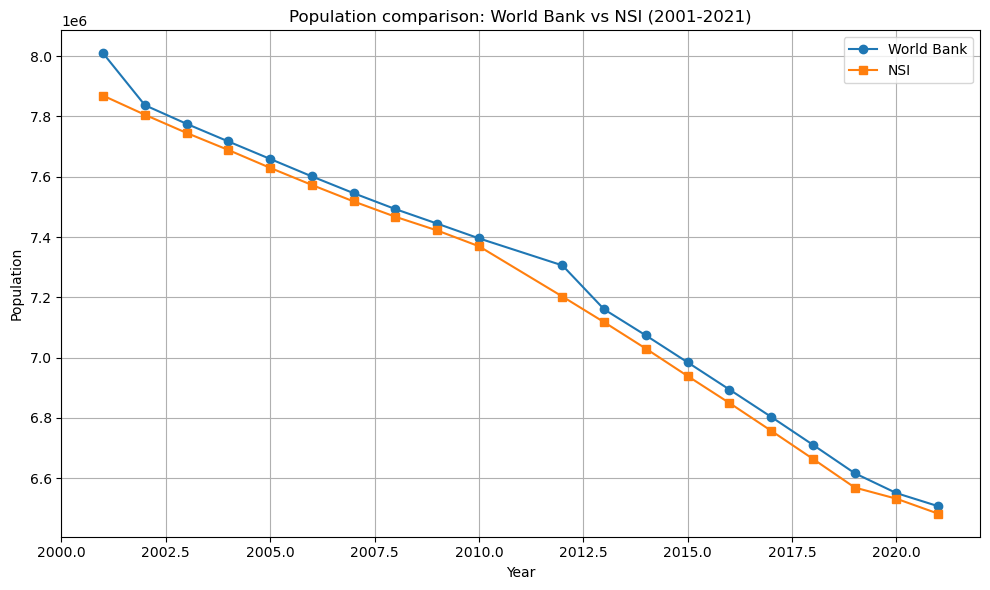

In [49]:
# visualization of the datasets and their respective differences

population_comparison = population_comparison.sort_values("year")

plt.figure(figsize=(10, 6))

plt.plot(
    population_comparison["year"],
    population_comparison["population_total_wb"],
    marker="o",
    label="World Bank"
)

plt.plot(
    population_comparison["year"],
    population_comparison["population_total_nsi"],
    marker="s",
    label="NSI"
)

plt.title("Population comparison: World Bank vs NSI (2001-2021)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visual comparison of overlapping population series

The chart shows that the World Bank and NSI population series follow a very similar downward trend over the overlapping period 2001–2021. The two lines are close to each other, which visually supports the earlier numerical comparison showing relatively small differences between the two sources.

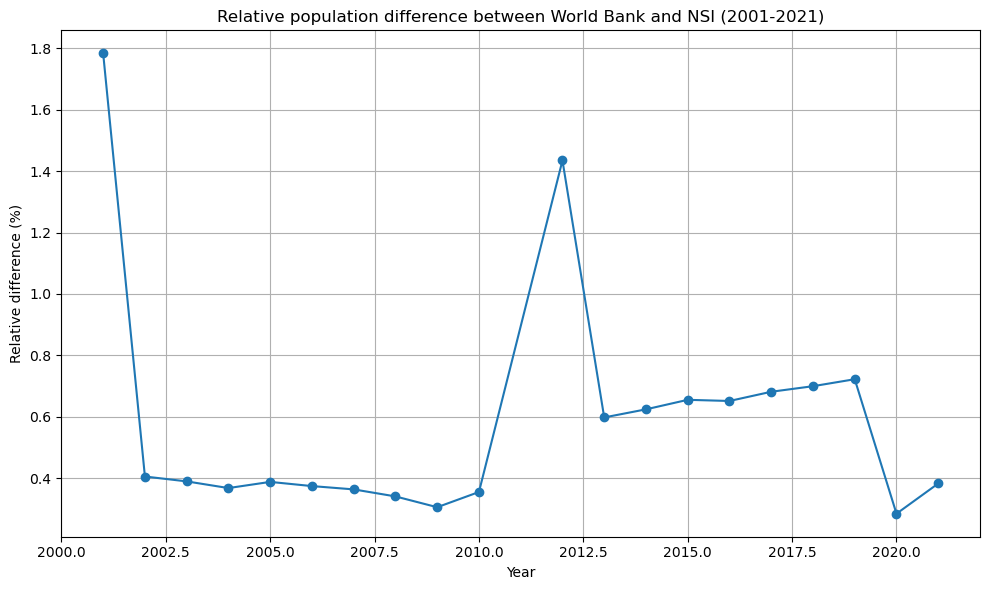

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    population_comparison["year"],
    population_comparison["relative_difference_pct"],
    marker="o"
)

plt.title("Relative population difference between World Bank and NSI (2001-2021)")
plt.xlabel("Year")
plt.ylabel("Relative difference (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Relative difference between World Bank and NSI population data

The relative difference plot shows how far the World Bank population values are from the NSI population values in percentage terms for the overlapping period 2001–2021. The values remain relatively low, which suggests that the two sources are broadly consistent, although small differences are present and should be acknowledged when interpreting the results.

## Interpretation of the overlap comparison

The comparison between World Bank and NSI population data for the overlapping years shows that the two series are very close, but not identical.

The average absolute difference is around 42,670 people, while the average relative difference is around 0.59%. This suggests that the two sources are broadly consistent, although some differences in revisions, update timing, or harmonization methods are likely present.